# CIFAR-10 Image Classification using CNN

A TensorFlow/Keras implementation of a CNN for CIFAR-10.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report


## Load Dataset

In [6]:
(X_train,y_train),(X_test,y_test)=cifar10.load_data()

print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3128s 18us/step
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


## Visualize Samples

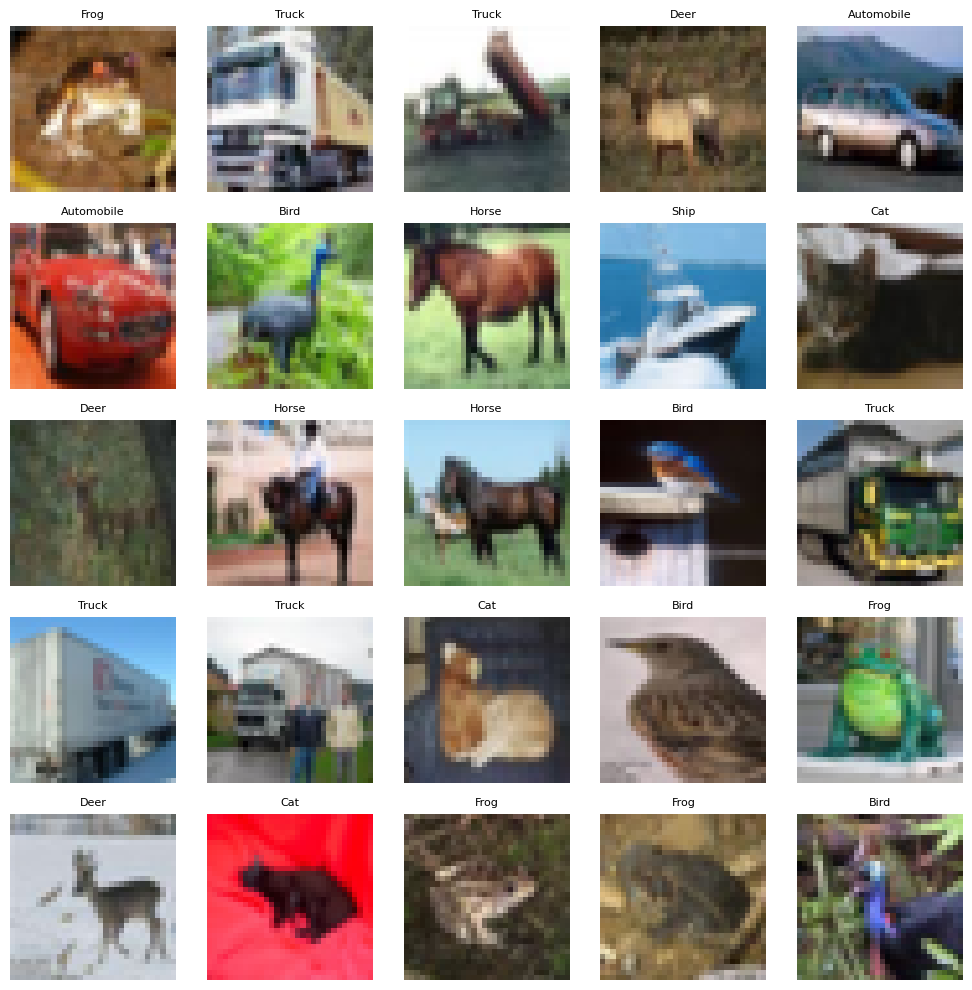

In [7]:
classes=["Airplane","Automobile","Bird","Cat","Deer","Dog","Frog","Horse","Ship","Truck"]

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i])
    plt.title(classes[y_train[i][0]],fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


## Preprocessing

In [8]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)


## CNN Model

In [9]:
model=Sequential([
Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
BatchNormalization(),
Conv2D(32,(3,3),activation='relu'),
MaxPooling2D(),
Dropout(0.25),

Conv2D(64,(3,3),activation='relu',padding='same'),
BatchNormalization(),
Conv2D(64,(3,3),activation='relu'),
MaxPooling2D(),
Dropout(0.25),

Flatten(),
Dense(256,activation='relu'),
Dropout(0.5),
Dense(10,activation='softmax')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 658,602 (2.51 MB)

 Trainable params: 658,410 (2.51 MB)

 Non-trainable params: 192 (768.00 B)

## Compile

In [10]:
model.compile(optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

## Train

In [11]:
history=model.fit(
X_train,
y_train,
epochs=10,
batch_size=64,
validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.3639 - loss: 1.7439 - val_accuracy: 0.3620 - val_loss: 2.0881
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5196 - loss: 1.3445 - val_accuracy: 0.6099 - val_loss: 1.1070
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5958 - loss: 1.1507 - val_accuracy: 0.6036 - val_loss: 1.1082
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6435 - loss: 1.0219 - val_accuracy: 0.6774 - val_loss: 0.9159
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6737 - loss: 0.9394 - val_accuracy: 0.6849 - val_loss: 0.9106
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6981 - loss: 0.8800 - val_accuracy: 0.7309 - val_loss: 0.7820
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7118 - loss: 0.8314 - val_accuracy: 0.7417 - val_loss: 0.7356
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7283 - loss: 0.7836 - val_accuracy: 

## Evaluate

In [12]:
loss,acc=model.evaluate(X_test,y_test)
print("Test Loss:",loss)
print("Test Accuracy:",acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7630 - loss: 0.6923
Test Loss: 0.6923409700393677
Test Accuracy: 0.7630000114440918


## Accuracy & Loss Curves

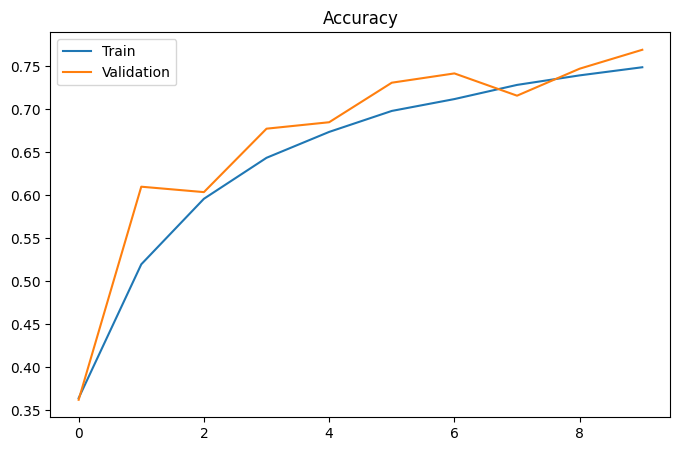

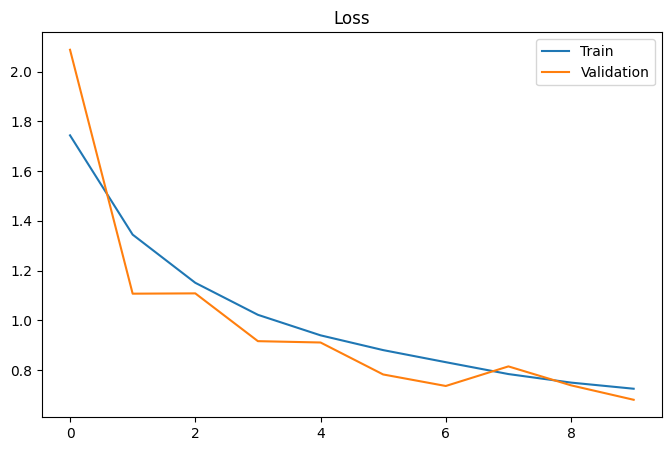

In [13]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')
plt.legend()
plt.title('Loss')
plt.show()


## Predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


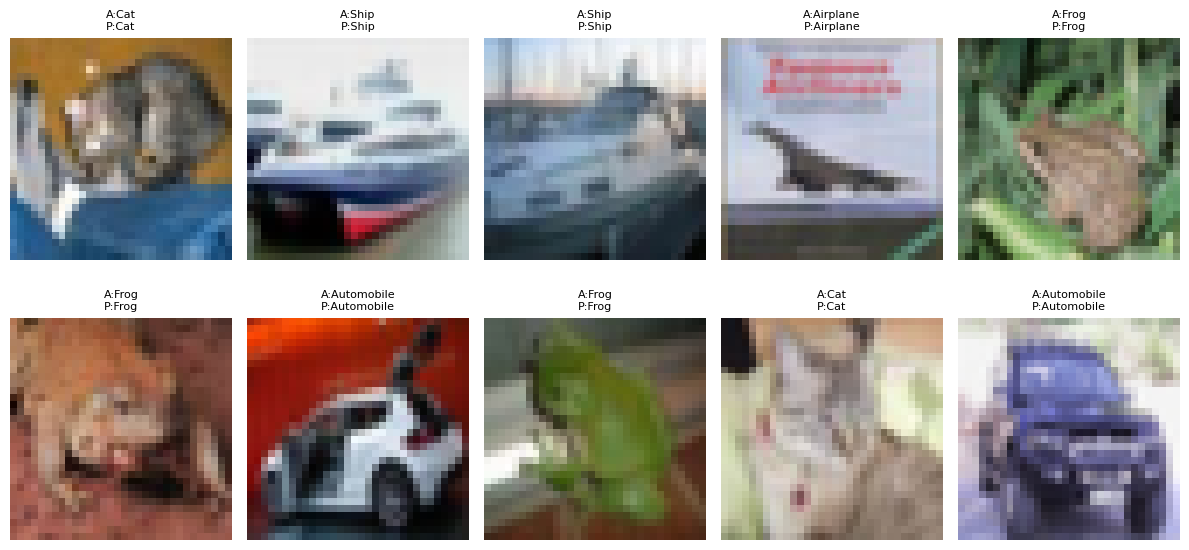

In [14]:
pred=model.predict(X_test)
pred_labels=np.argmax(pred,axis=1)
true_labels=np.argmax(y_test,axis=1)

plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i])
    plt.title(f'A:{classes[true_labels[i]]}\nP:{classes[pred_labels[i]]}',fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()


## Confusion Matrix

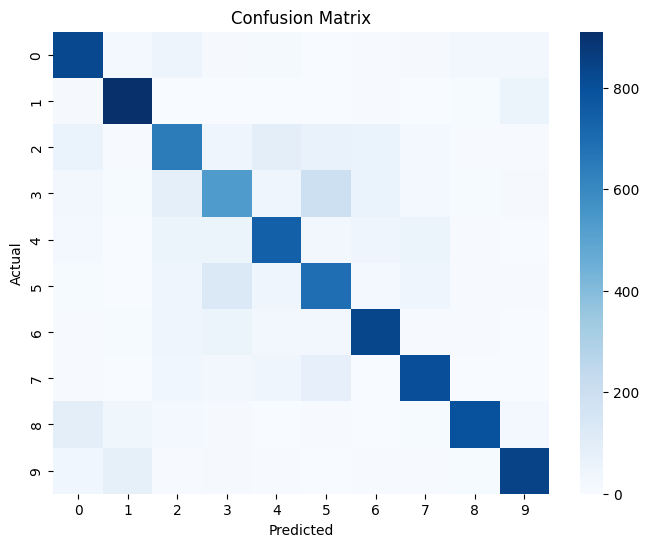

              precision    recall  f1-score   support

    Airplane       0.75      0.83      0.79      1000
  Automobile       0.84      0.91      0.88      1000
        Bird       0.66      0.65      0.65      1000
         Cat       0.61      0.53      0.57      1000
        Deer       0.73      0.74      0.74      1000
         Dog       0.63      0.69      0.66      1000
        Frog       0.80      0.83      0.82      1000
       Horse       0.82      0.81      0.81      1000
        Ship       0.92      0.80      0.85      1000
       Truck       0.87      0.84      0.86      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



In [15]:
cm=confusion_matrix(true_labels,pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm,cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(true_labels,pred_labels,target_names=classes))


## Conclusion
This project builds a CNN to classify CIFAR-10 images. It demonstrates image preprocessing, convolutional feature extraction, model training, evaluation, and visualization of predictions.